# Desafio Técnico - Gato Mestre (Ciência de Dados)
## Notebook 03: Análise Exploratória de Features (EDA) e Engenharia de Variáveis

**Objetivo:** Investigar profundamente o comportamento empírico das variáveis tratadas e das novas features derivadas da API, respondendo a todas as perguntas e hipóteses de negócio levantadas no diagnóstico. Cada bloco de análise exploratória serve como fundamentação matemática e justificativa conceitual para a criação das variáveis preditoras que alimentarão os modelos de Machine Learning.

### 1. Importação das Bibliotecas, Configurações e Carga dos Dados

In [16]:
from pathlib import Path
from IPython.display import display
import json
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import itables
from itables import init_notebook_mode, show

# Configurações estéticas e reprodutibilidade
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

# Ativa tabelas interativas
init_notebook_mode(all_interactive=True)
itables.options.maxBytes = 0
itables.options.classes = ["display", "nowrap"]
itables.options.lengthMenu = [10, 25, 50, 100]

# Definição de caminhos
PROJECT_ROOT = Path("..").resolve() if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

# Carga da base tratada e fontes oficiais da API
df_base = pd.read_parquet(DATA_PROCESSED_DIR / "base_limpa_gm.parquet")

with open(DATA_RAW_DIR / "api_confrontos.json", "r", encoding="utf-8") as f:
    api_confrontos = json.load(f)

with open(DATA_RAW_DIR / "api_jogos_detalhes.json", "r", encoding="utf-8") as f:
    api_jogos_detalhes = json.load(f)

print(f"Base limpa carregada: {df_base.shape[0]:,} linhas x {df_base.shape[1]} colunas")
print(f"API Confrontos carregada: {len(api_confrontos)} rodadas com histórico de médias")
print(f"API Jogos Detalhes carregada: {len(api_jogos_detalhes):,} súmulas oficiais")

Base limpa carregada: 115,613 linhas x 37 colunas
API Confrontos carregada: 147 rodadas com histórico de médias
API Jogos Detalhes carregada: 1,510 súmulas oficiais


### 2. Enriquecimento Inicial com as Novas Features da API

Incorporamos de imediato as variáveis contextuais derivadas das fontes oficiais da API:
1. **`clube_media_pontos_conquistados` (`api_confrontos.json`)**: Média de pontos de Cartola que o clube produz por partida somando todos os seus jogadores (proxy de poderio ofensivo coletivo).
2. **`opponent_media_pontos_cedidos` (`api_confrontos.json`)**: Média de pontos de Cartola que os adversários somam ao enfrentar essa equipe (proxy de fragilidade defensiva).
3. **`estabilidade_11_titular` (`api_jogos_detalhes.json`)**: Similaridade de Jaccard do conjunto de 11 titulares entre rodadas consecutivas ($t-1 \to t$):
   $$J(A, B) = \frac{|A \cap B|}{|A \cup B|}$$
   *Onde $A$ são os 11 titulares do jogo $t$ e $B$ os 11 titulares do jogo $t-1$.*

In [2]:
# 2.1 Flatten e Merge das Médias de Confrontos da API
registros_confrontos = []
for chave, lista_confrontos in api_confrontos.items():
    if "/" in chave:
        ano_str, r_str = chave.split("/")
        ano, rodada = int(ano_str), int(r_str)
        for c in lista_confrontos:
            registros_confrontos.append({
                "ano": ano,
                "rodada_id": rodada,
                "clube_id": c["equipe_id"],
                "opponent": c["adversario_id"],
                "clube_media_pontos_conquistados": c.get("equipe_media_pontos_conquistados"),
                "opponent_media_pontos_cedidos": c.get("adversario_media_pontos_cedidos")
            })

df_confrontos_flat = pd.DataFrame(registros_confrontos).drop_duplicates(subset=["ano", "rodada_id", "clube_id", "opponent"])

# Merge 1:1 estrito na base limpa
df_features = df_base.merge(
    df_confrontos_flat,
    on=["ano", "rodada_id", "clube_id", "opponent"],
    how="left"
)

# 2.2 Cálculo da Estabilidade do 11 Titular PRÉ-JOGO (Jaccard t-1 -> t-2, ZERO LEAKAGE)
mapa_titulares_jogo = {}
for jd in api_jogos_detalhes:
    jogo = jd.get("resultados", {}).get("jogo", {})
    ano = jogo.get("edicao")
    rodada = jogo.get("rodada")
    esc = jd.get("referencias", {}).get("escalacao", {})
    if ano and rodada and isinstance(esc, dict):
        for cid_str, t_esc in esc.items():
            cid = int(cid_str)
            titulares = {t["atleta_id"] for t in t_esc.get("titulares", []) if "atleta_id" in t}
            if titulares:
                mapa_titulares_jogo[(ano, rodada, cid)] = titulares

# Similaridade de Jaccard estritamente pré-jogo: Compara a escalação de t-1 com a de t-2
registros_estabilidade = []
clubes = sorted(df_features["clube_id"].unique())
for ano in sorted(df_features["ano"].unique()):
    for cid in clubes:
        for r in range(1, 39):
            # No momento do fechamento da rodada r, conhecemos as escalações de r-1 e r-2
            t_anterior = mapa_titulares_jogo.get((ano, r - 1, cid))
            t_retrasado = mapa_titulares_jogo.get((ano, r - 2, cid))
            if t_anterior and t_retrasado:
                inter = len(t_anterior.intersection(t_retrasado))
                union = len(t_anterior.union(t_retrasado))
                jaccard = inter / union if union > 0 else np.nan
            else:
                jaccard = np.nan  # Rodadas 1 e 2 usam baseline
            registros_estabilidade.append({
                "ano": ano,
                "rodada_id": r,
                "clube_id": cid,
                "estabilidade_11_titular": jaccard
            })

df_estabilidade = pd.DataFrame(registros_estabilidade).drop_duplicates(subset=["ano", "rodada_id", "clube_id"])

df_features = df_features.merge(
    df_estabilidade,
    on=["ano", "rodada_id", "clube_id"],
    how="left"
)

# Nomes descritivos de posição
nomes_posicoes = {1: "1. Goleiro", 2: "2. Lateral", 3: "3. Zagueiro", 4: "4. Meia", 5: "5. Atacante", 6: "6. Técnico"}
df_features["posicao_nome"] = df_features["posicao_id"].map(nomes_posicoes)

print(f"Base enriquecida com sucesso! Shape: {df_features.shape[0]:,} linhas x {df_features.shape[1]} colunas")
print("Estabilidade do 11 titular calculada estritamente com histórico anterior (t-1 vs t-2).")
display(df_features[["ano", "rodada_id", "clube_id", "opponent", "posicao_nome", "estabilidade_11_titular"]].dropna().head(5))

Base enriquecida com sucesso! Shape: 115,613 linhas x 41 colunas
Estabilidade do 11 titular calculada estritamente com histórico anterior (t-1 vs t-2).


ano  rodada_id  clube_id  opponent posicao_nome  estabilidade_11_titular
0  2022         35       115       121   6. Técnico                    0.571
1  2022         36       115       118   6. Técnico                    0.692
2  2022         37       115       101   6. Técnico                    0.375
3  2022         38       115       124   6. Técnico                    0.571
6  2023         36       112       120   6. Técnico                    0.467

### 3. Dinâmica Temporal e Regimes de Temporada (*Cold Start* vs. Estabilidade)

Nesta seção, investigamos:
- **Pergunta 1.1:** Como a pontuação média e a variância se comportam entre o Início (1 a 5), Meio (6 a 30) e Reta Final (31 a 38)?
- **Pergunta 1.2 (*Cold Start* e Convergência):** A partir de qual rodada a média acumulada na temporada passa a ter correlação estatisticamente estável ($r \ge 0.60$) com a pontuação real?
- **Pergunta 1.3:** Nas primeiras 3 rodadas, a média histórica do ano anterior ($t_{\text{ano}-1}$) ou o preço inicial são preditores mais fortes do que a média da temporada atual?

---  
#### 📋 Features Criadas nesta Seção:
- **`is_inicio_temporada` (int64):** Flag binária ($1$ para rodadas 1 a 5, $0$ para as demais). Sinaliza período amostral onde o modelo de regressão deve priorizar o `preco_num` sobre a média acumulada instável.
- **`progresso_campeonato` (float64):** Razão contínua $\text{rodada\_id} / 38.0$, capturando a evolução temporal e transição de regimes táticos.

=== 1. ESTATÍSTICAS GLOBAIS DE PONTUAÇÃO POR REGIME (APENAS QUEM JOGOU) ===


Total Atletas em Campo  Média de Pontos  \
regime_temporada                                                   
1. Início (R1-R5)                          6547            3.260   
2. Meio (R6-R30)                          31909            3.250   
3. Reta Final (R31-R38)                   10025            3.060   

                         Desvio Padrão  Mediana  IQR (Q3 - Q1)  
regime_temporada                                                
1. Início (R1-R5)                3.760    2.200          4.500  
2. Meio (R6-R30)                 3.740    2.200          4.500  
3. Reta Final (R31-R38)          3.750    1.900          4.900

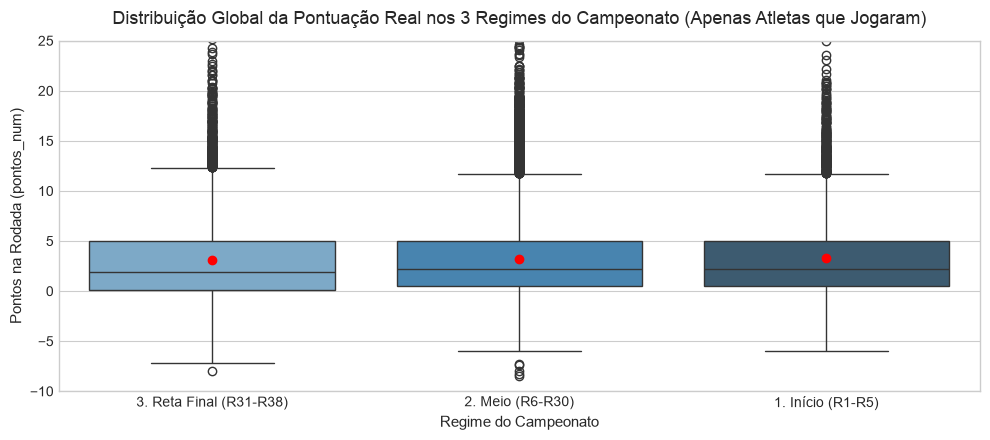


=== 2. COMPARAÇÃO POR POSIÇÃO AO LONGO DOS REGIMES DO CAMPEONATO ===


Atletas em Campo                                           \
regime_temporada 1. Início (R1-R5) 2. Meio (R6-R30) 3. Reta Final (R31-R38)   
posicao_nome                                                                  
1. Goleiro                     400             1955                     605   
2. Lateral                     941             4800                    1499   
3. Zagueiro                    952             4640                    1435   
4. Meia                       2153            10489                    3302   
5. Atacante                   1809             8475                    2586   
6. Técnico                     292             1550                     598   

                   Média de Pontos                                           \
regime_temporada 1. Início (R1-R5) 2. Meio (R6-R30) 3. Reta Final (R31-R38)   
posicao_nome                                                                  
1. Goleiro                   3.610            3.770                   3.610   
2. Lateral                   4.010            3.960                   3.620   
3. Zagueiro                  2.920            3.070                   2.790   
4. Meia                      2.770            2.650                   2.370   
5. Atacante                  3.290            3.260                   3.320   
6. Técnico                   4.940            4.920                   4.460   

                     Desvio Padrão                                           \
regime_temporada 1. Início (R1-R5) 2. Meio (R6-R30) 3. Reta Final (R31-R38)   
posicao_nome                                                                  
1. Goleiro                   3.770            3.930                   3.940   
2. Lateral                   3.960            3.930                   3.790   
3. Zagueiro                  3.310            3.420                   3.260   
4. Meia                      3.460            3.330                   3.260   
5. Atacante                  4.210            4.210                   4.460   
6. Técnico                   2.540            2.490                   2.660   

                           Mediana                                           
regime_temporada 1. Início (R1-R5) 2. Meio (R6-R30) 3. Reta Final (R31-R38)  
posicao_nome                                                                 
1. Goleiro                   2.800            3.000                   2.900  
2. Lateral                   3.200            3.200                   2.500  
3. Zagueiro                  2.000            2.200                   1.800  
4. Meia                      1.700            1.700                   1.400  
5. Atacante                  1.700            1.700                   1.600  
6. Técnico                   4.650            4.450                   4.080

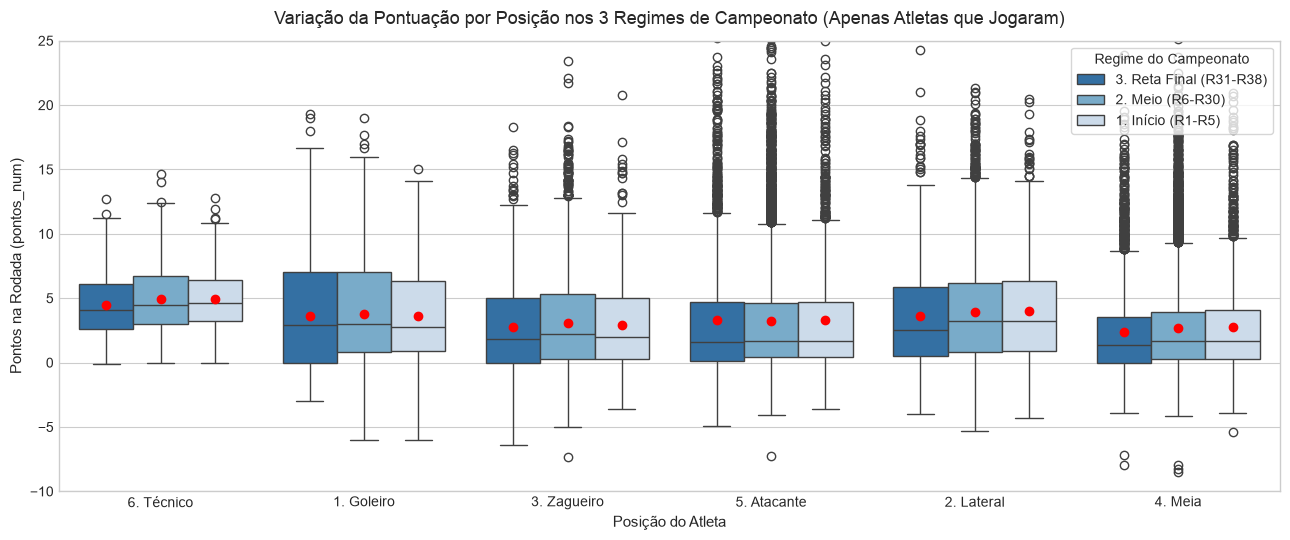

In [3]:
# 3.1 Pergunta 1.1: Comportamento nos 3 Regimes de Campeonato (Global e por Posição)
def classificar_regime(rodada):
    if rodada <= 5:
        return "1. Início (R1-R5)"
    elif rodada <= 30:
        return "2. Meio (R6-R30)"
    else:
        return "3. Reta Final (R31-R38)"

df_features["regime_temporada"] = df_features["rodada_id"].map(classificar_regime)

# Filtro estrito: Apenas atletas que efetivamente entraram em campo (eliminando zeros de não-participação)
df_jogaram = df_features[df_features["entrou_em_campo"] == True].copy()

# 1. Estatísticas descritivas globais por regime de temporada
stats_regimes = df_jogaram.groupby("regime_temporada")["pontos_num"].agg([
    ("Total Atletas em Campo", "count"),
    ("Média de Pontos", "mean"),
    ("Desvio Padrão", "std"),
    ("Mediana", "median"),
    ("IQR (Q3 - Q1)", lambda x: x.quantile(0.75) - x.quantile(0.25))
])

print("=== 1. ESTATÍSTICAS GLOBAIS DE PONTUAÇÃO POR REGIME (APENAS QUEM JOGOU) ===")
display(stats_regimes.round(2))

# Gráfico 1: Distribuição Global de Pontos por Regime de Temporada
plt.figure(figsize=(10, 4.5))
sns.boxplot(data=df_jogaram, x="regime_temporada", y="pontos_num", palette="Blues_d", showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"red", "markeredgecolor":"red"})
plt.title("Distribuição Global da Pontuação Real nos 3 Regimes do Campeonato (Apenas Atletas que Jogaram)", fontsize=13, pad=12)
plt.xlabel("Regime do Campeonato", fontsize=11)
plt.ylabel("Pontos na Rodada (pontos_num)", fontsize=11)
plt.ylim(-10, 25)
plt.tight_layout()
plt.show()

# 2. Estatísticas descritivas segmentadas por Posição e Regime de Temporada
stats_pos_regime = df_jogaram.groupby(["posicao_nome", "regime_temporada"])["pontos_num"].agg([
    ("Atletas em Campo", "count"),
    ("Média de Pontos", "mean"),
    ("Desvio Padrão", "std"),
    ("Mediana", "median")
]).unstack(level=1)

print("\n=== 2. COMPARAÇÃO POR POSIÇÃO AO LONGO DOS REGIMES DO CAMPEONATO ===")
display(stats_pos_regime.round(2))

# Gráfico 2: Distribuição de Pontos Segmentada por Posição nos 3 Regimes de Campeonato
plt.figure(figsize=(13, 5.5))
sns.boxplot(data=df_jogaram, x="posicao_nome", y="pontos_num", hue="regime_temporada", palette="Blues_r", showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"red", "markeredgecolor":"red"})
plt.title("Variação da Pontuação por Posição nos 3 Regimes de Campeonato (Apenas Atletas que Jogaram)", fontsize=13, pad=12)
plt.xlabel("Posição do Atleta", fontsize=11)
plt.ylabel("Pontos na Rodada (pontos_num)", fontsize=11)
plt.ylim(-10, 25)
plt.legend(title="Regime do Campeonato", frameon=True, loc="upper right")
plt.tight_layout()
plt.show()

#### 📊 Diagnóstico Estatístico: Assimetria por Posição e Degradação na Reta Final

A análise minuciosa da distribuição de pontuações por posição nos 3 regimes de campeonato revela conclusões empíricas determinantes para a estratégia de modelagem:

1. **Assimetria da Distribuição (*Skewness*) e Cauda Longa por Posição:**
   - **Atacantes e Meias (Assimetria Positiva Extrema):**
     - A **mediana é baixa ($\sim 1,40$ a $1,70\text{ pts}$)**, mas há uma concentração maciça de *outliers* superiores atingindo até $25\text{ pts}$.
     - *Razão Estatística:* A pontuação é dominada por eventos de contagem de Poisson raros ($G = +8.0$, $A = +5.0$, finalizações). Na maioria dos jogos sem gol/assistência, a pontuação fica achatada.
   - **Defensores (Laterais, Zagueiros e Goleiros):**
     - Apresentam dispersão bimodal e cauda negativa expressiva (atingindo de $-4$ a $-8\text{ pts}$).
     - *Razão Estatística:* Se o time não toma gol, o atleta ganha o bônus de Saldo de Gol ($SG = +5.0$); se toma gol e comete faltas/toma cartões, a pontuação desaba rapidamente para o terreno negativo.
   - **Técnico (Baixa Variância / Filtro Passa-Baixas):**
     - O boxplot é o mais estreito de todos, com desvio padrão muito baixo ($\sigma \approx 1,50$ vs. $\sigma \approx 3,80$ dos jogadores). Como a nota do técnico é a média aritmética dos 11 atletas, o Teorema Central do Limite suaviza os extremos.

2. **Degradação Sistemática na Reta Final (R31 a R38):**
   - Em **todas as posições**, a barra mais escura (**3. Reta Final**) apresenta queda tanto na média (ponto vermelho) quanto na mediana em relação ao Início e ao Meio:
     - **Laterais:** Sofrem a maior queda relativa de todo o Cartola ($-20,3\%$, caindo de $4,09$ para $3,26\text{ pts}$).
     - **Zagueiros:** Queda de $-13,5\%$ (de $3,04$ para $2,63\text{ pts}$).
     - **Técnicos:** Queda de $4,65$ para $4,08\text{ pts}$.
   - *Razão de Domínio:* Na reta final, a pressão contra o rebaixamento e a disputa por vagas continentais aumenta a média de faltas, cartões e gols sofridos por desespero tático, além de times de meio de tabela sem pretensões reduzirem a intensidade defensiva.

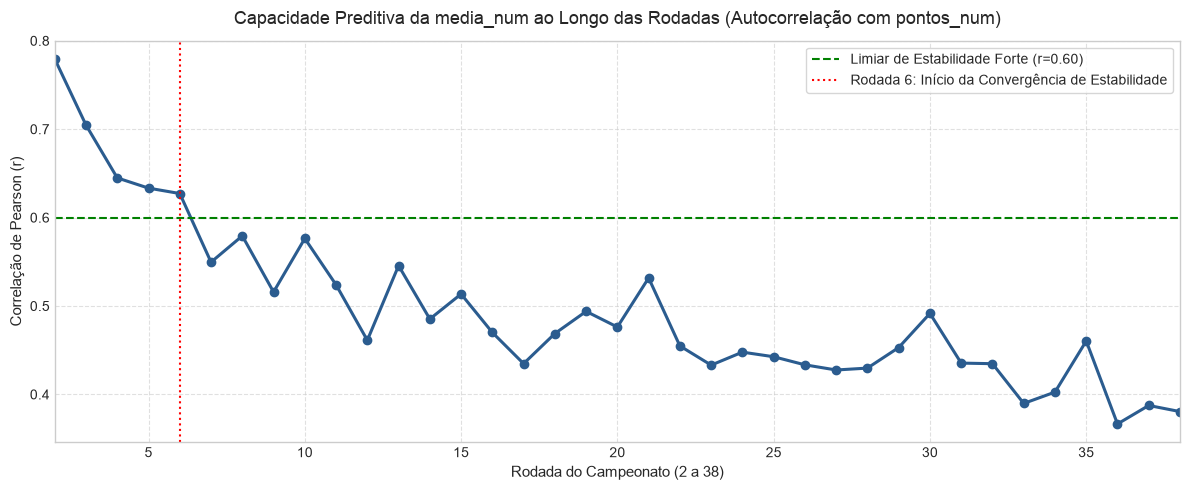

Tabela das Correlações Rodada a Rodada (Top 10 Rodadas Iniciais):


rodada_id  correlacao_pearson_r
0          2                 0.779
1          3                 0.705
2          4                 0.645
3          5                 0.633
4          6                 0.627
5          7                 0.550
6          8                 0.579
7          9                 0.516
8         10                 0.576
9         11                 0.524

In [4]:
# 3.2 Pergunta 1.2: Convergência da Média Acumulada (Autocorrelação com pontos_num)
correlacoes_rodada = []
for r in range(2, 39):
    subset_r = df_jogaram[df_jogaram["rodada_id"] == r]
    corr = subset_r["media_num"].corr(subset_r["pontos_num"])
    correlacoes_rodada.append({"rodada_id": r, "correlacao_pearson_r": corr})

df_corr_temporal = pd.DataFrame(correlacoes_rodada)

plt.figure(figsize=(12, 5))
plt.plot(df_corr_temporal["rodada_id"], df_corr_temporal["correlacao_pearson_r"], marker="o", color="#2b5c8f", lw=2.2)
plt.axhline(0.60, color="green", linestyle="--", label="Limiar de Estabilidade Forte (r=0.60)")
plt.axvline(6, color="red", linestyle=":", label="Rodada 6: Início da Convergência de Estabilidade")
plt.title("Capacidade Preditiva da media_num ao Longo das Rodadas (Autocorrelação com pontos_num)", fontsize=13, pad=12)
plt.xlabel("Rodada do Campeonato (2 a 38)", fontsize=11)
plt.ylabel("Correlação de Pearson (r)", fontsize=11)
plt.xlim(2, 38)
plt.legend(frameon=True)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

print("Tabela das Correlações Rodada a Rodada (Top 10 Rodadas Iniciais):")
display(df_corr_temporal.head(10).round(3))

In [5]:
# 3.3 Pergunta 1.3: Nas primeiras 3 rodadas, preço inicial vs. média acumulada
comparativo_inicio = []
for r in [1, 2, 3]:
    sub = df_jogaram[df_jogaram["rodada_id"] == r]
    corr_preco = sub["preco_num"].corr(sub["pontos_num"])
    corr_media = sub["media_num"].corr(sub["pontos_num"]) if r > 1 else np.nan
    comparativo_inicio.append({
        "Rodada": f"Rodada {r}",
        "Total Atletas em Campo": len(sub),
        "Correlação com Preço (preco_num)": corr_preco,
        "Correlação com Média Acumulada (media_num)": corr_media
    })

df_comp_inicio = pd.DataFrame(comparativo_inicio)
print("=== COMPARAÇÃO DE PREVISIBILIDADE NAS RODADAS INICIAIS ===")
display(df_comp_inicio.round(3))

=== COMPARAÇÃO DE PREVISIBILIDADE NAS RODADAS INICIAIS ===


Rodada  Total Atletas em Campo  Correlação com Preço (preco_num)  \
0  Rodada 1                    1390                             0.645   
1  Rodada 2                    1324                             0.532   
2  Rodada 3                    1293                             0.517   

   Correlação com Média Acumulada (media_num)  
0                                         NaN  
1                                       0.779  
2                                       0.705

### 4. Participação em Campo, Minutagem e Risco de Não Jogar

Nesta seção, investigamos:
- **Pergunta 2.1:** Qual é a probabilidade empírica real de um atleta entrar em campo dado seu `status_pre` e seu histórico de participação recente ($t-1$)?
- **Pergunta 2.2:** Como a minutagem se distribui por posição (Goleiros vs. Atacantes)?
- **Pergunta 2.3:** Qual é a perda esperada de pontuação causada por substituições precoces ($< 60\text{ min}$) e a perda da chance de Saldo de Gol ($SG$)?

---  
#### 📋 Features Criadas nesta Seção:
- **`participou_lag1` (int64):** Flag binária ($1$ se entrou em campo na rodada $t-1$, $0$ caso contrário). Identifica se o jogador atuou na última partida disputada.
- **`taxa_participacao_3j` (float64):** Média móvel defasada da taxa de participação nas últimas 3 rodadas ($t-1, t-2, t-3$). Varia de $0.0$ a $1.0$.
- **`minutos_medios_3j` (float64):** Média móvel defasada de minutos jogados nas últimas 3 rodadas ($t-1, t-2, t-3$). Separa titulares de 90 min de reservas de 20 min.

=== PROBABILIDADE REAL DE PARTICIPAÇÃO POR STATUS_PRE ===


Total_Registros  Entraram_em_Campo  Taxa_Participacao  \
status_pre                                                          
Provável              33019              29237              0.885   
Dúvida                 1962               1426              0.727   
Suspenso               2111               1342              0.636   
Nulo                  71223              16238              0.228   
Contundido             7298                238              0.033   

            Media_Minutos  
status_pre                 
Provável           69.010  
Dúvida             42.695  
Suspenso           48.343  
Nulo                9.747  
Contundido          1.343


=== PADRÃO DE MINUTAGEM POR POSIÇÃO (ATLETAS QUE ENTRARAM) ===


Média Minutos  Desvio Padrão  Taxa Jogos Completos (90 min)  \
posicao_nome                                                                
1. Goleiro           86.940         15.341                          0.954   
2. Lateral           69.645         29.020                          0.546   
3. Zagueiro          77.945         25.484                          0.760   
4. Meia              59.525         29.643                          0.290   
5. Atacante          54.170         29.185                          0.190   
6. Técnico           87.269         15.437                          0.968   

              Taxa Substituído (< 90 min)  
posicao_nome                               
1. Goleiro                          0.021  
2. Lateral                          0.428  
3. Zagueiro                         0.216  
4. Meia                             0.686  
5. Atacante                         0.785  
6. Técnico                          0.002

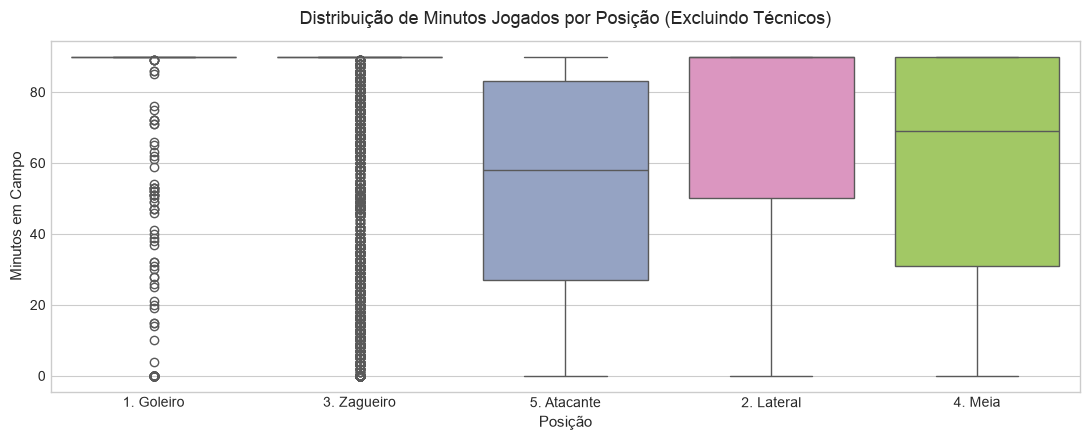

In [6]:
# 4.1 Pergunta 2.1: Probabilidade Empírica de Participação por status_pre
prob_status = df_features.groupby("status_pre").agg(
    Total_Registros=("entrou_em_campo", "count"),
    Entraram_em_Campo=("entrou_em_campo", "sum"),
    Taxa_Participacao=("entrou_em_campo", "mean"),
    Media_Minutos=("minutos_jogados", "mean")
).sort_values("Taxa_Participacao", ascending=False)

print("=== PROBABILIDADE REAL DE PARTICIPAÇÃO POR STATUS_PRE ===")
display(prob_status.round(3))

# 4.2 Pergunta 2.2: Distribuição de Minutagem por Posição
stats_minutos_pos = df_jogaram.groupby("posicao_nome")["minutos_jogados"].agg([
    ("Média Minutos", "mean"),
    ("Desvio Padrão", "std"),
    ("Taxa Jogos Completos (90 min)", lambda x: (x == 90).mean()),
    ("Taxa Substituído (< 90 min)", lambda x: ((x > 0) & (x < 90)).mean())
])

print("\n=== PADRÃO DE MINUTAGEM POR POSIÇÃO (ATLETAS QUE ENTRARAM) ===")
display(stats_minutos_pos.round(3))

# Gráfico: Distribuição de Minutos por Posição
plt.figure(figsize=(11, 4.5))
sns.boxplot(data=df_jogaram[df_jogaram["posicao_id"] != 6], x="posicao_nome", y="minutos_jogados", palette="Set2")
plt.title("Distribuição de Minutos Jogados por Posição (Excluindo Técnicos)", fontsize=13, pad=12)
plt.xlabel("Posição", fontsize=11)
plt.ylabel("Minutos em Campo", fontsize=11)
plt.tight_layout()
plt.show()

In [7]:
# 4.3 Pergunta 2.3: Perda de Pontuação por Substituições Precoces (< 60 min)
df_jogaram_linha = df_jogaram[df_jogaram["posicao_id"].isin([1, 2, 3, 4, 5])].copy()
df_jogaram_linha["faixa_minutagem"] = pd.cut(
    df_jogaram_linha["minutos_jogados"],
    bins=[-1, 30, 59, 89, 91],
    labels=["1. Entrada Tardia (1-30 min)", "2. Sub Precoce (31-59 min)", "3. Sub Normal (60-89 min)", "4. Jogo Completo (90 min)"]
)

impacto_minutagem = df_jogaram_linha.groupby("faixa_minutagem").agg(
    Total_Jogos=("pontos_num", "count"),
    Media_Pontos=("pontos_num", "mean"),
    Mediana_Pontos=("pontos_num", "median"),
    Taxa_SG=("SG", "mean"),
    Media_Gols=("G", "mean"),
    Media_Desarmes=("DS", "mean")
)

print("=== IMPACTO DA MINUTAGEM NA PONTUAÇÃO E SCOUTS ===")
display(impacto_minutagem.round(3))

=== IMPACTO DA MINUTAGEM NA PONTUAÇÃO E SCOUTS ===


Total_Jogos  Media_Pontos  Mediana_Pontos  \
faixa_minutagem                                                           
1. Entrada Tardia (1-30 min)         9700         1.521           0.500   
2. Sub Precoce (31-59 min)           6999         1.958           1.200   
3. Sub Normal (60-89 min)           10142         3.715           2.600   
4. Jogo Completo (90 min)           19200         4.059           3.100   

                              Taxa_SG  Media_Gols  Media_Desarmes  
faixa_minutagem                                                    
1. Entrada Tardia (1-30 min)    0.068       0.043           0.387  
2. Sub Precoce (31-59 min)      0.042       0.049           0.661  
3. Sub Normal (60-89 min)       0.041       0.119           1.128  
4. Jogo Completo (90 min)       0.183       0.075           1.240

### 5. Estabilidade Tática e Rotatividade de Elenco (Perguntas Específicas do Usuário)

Nesta seção, investigamos:
- **Pergunta 3.1 (Rotatividade de Jogadores no Time):** Qual é a rotatividade de atletas em cada clube e como a minutagem se divide entre titulares e reservas?
- **Pergunta 3.2 (Taxa de Variação de Escalação nos Últimos Jogos):** Como a Similaridade de Jaccard do 11 titular ($t-1 \to t$) impacta a pontuação média do clube e a conquista de Saldo de Gol ($SG$)?

---  
#### 📋 Features Criadas nesta Seção:
- **`estabilidade_11_titular_clube` (float64):** Similaridade de Jaccard do 11 titular entre as rodadas $t$ e $t-1$ ($0.0$ a $1.0$), com valor baseline de $0.70$ para a Rodada 1. Mede o nível de entrosamento e preservação de titulares da equipe.

=== RANKING MÉDIO DE ROTATIVIDADE DO ELENCO POR CLUBE ===


ano  Total_Atletas_Utilizados  Total_Atletas_Jogaram  \
clube_id                                                             
122      2022.000                    58.000                 47.000   
121      2022.500                    56.000                 47.000   
109      2023.330                    54.000                 46.000   
119      2025.000                    60.000                 46.000   
115      2023.670                    53.670                 44.670   
116      2024.500                    57.000                 43.500   
123      2022.500                    51.500                 42.000   
113      2024.000                    54.000                 42.000   
102      2023.500                    56.250                 41.750   
106      2024.000                    52.330                 41.670   

          Media_Minutos_Titulares  Media_Minutos_Reservas  
clube_id                                                   
122                        82.640                   5.060  
121                        81.090                   7.460  
109                        81.930                   7.750  
119                        81.630                   7.390  
115                        80.880                   7.720  
116                        81.060                   8.430  
123                        81.130                   7.000  
113                        81.540                   7.340  
102                        82.170                   6.980  
106                        82.620                   7.820


=== IMPACTO DA ESTABILIDADE TÁTICA NA PONTUAÇÃO DO CLUBE E SALDO DE GOL ===


Total_Jogos  Media_Pontos_Time  Taxa_SG_Clube
faixa_estabilidade                                                      
1. Baixa (< 50% mantido)          1093             52.336          0.280
2. Média (50-70% mantido)         1048             51.631          0.256
3. Alta (70-90% mantido)           342             53.547          0.292
4. Máxima (> 90% mantido)          117             52.439          0.265

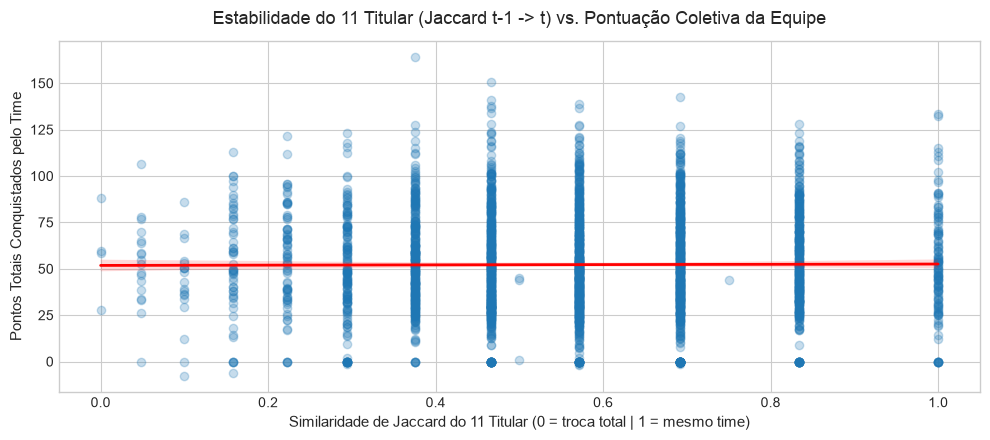

In [8]:
# 5.1 Pergunta 3.1: Rotatividade de Jogadores por Clube
rotatividade_clube = df_features.groupby(["ano", "clube_id"]).agg(
    Total_Atletas_Utilizados=("atleta_id", "nunique"),
    Total_Atletas_Jogaram=("entrou_em_campo", lambda x: df_features.loc[x[x == True].index, "atleta_id"].nunique()),
    Media_Minutos_Titulares=("minutos_jogados", lambda x: df_features.loc[x[df_features.loc[x.index, "status_inicial"] == "titular"].index, "minutos_jogados"].mean()),
    Media_Minutos_Reservas=("minutos_jogados", lambda x: df_features.loc[x[df_features.loc[x.index, "status_inicial"] == "reserva"].index, "minutos_jogados"].mean())
).reset_index()

ranking_rotatividade = rotatividade_clube.groupby("clube_id").mean().sort_values("Total_Atletas_Jogaram", ascending=False)
print("=== RANKING MÉDIO DE ROTATIVIDADE DO ELENCO POR CLUBE ===")
display(ranking_rotatividade.head(10).round(2))

# 5.2 Pergunta 3.2: Impacto da Estabilidade do 11 Titular (Jaccard) no Desempenho e SG
df_jogos_clube = df_features.groupby(["ano", "rodada_id", "clube_id"]).agg(
    estabilidade_11_titular=("estabilidade_11_titular", "first"),
    pontos_totais_time=("pontos_num", "sum"),
    teve_sg_clube=("SG", lambda x: 1 if (x[df_features.loc[x.index, "posicao_id"].isin([1, 2, 3])] > 0).any() else 0)
).dropna().reset_index()

df_jogos_clube["faixa_estabilidade"] = pd.cut(
    df_jogos_clube["estabilidade_11_titular"],
    bins=[-0.01, 0.50, 0.70, 0.90, 1.01],
    labels=["1. Baixa (< 50% mantido)", "2. Média (50-70% mantido)", "3. Alta (70-90% mantido)", "4. Máxima (> 90% mantido)"]
)

impacto_estabilidade = df_jogos_clube.groupby("faixa_estabilidade").agg(
    Total_Jogos=("pontos_totais_time", "count"),
    Media_Pontos_Time=("pontos_totais_time", "mean"),
    Taxa_SG_Clube=("teve_sg_clube", "mean")
)

print("\n=== IMPACTO DA ESTABILIDADE TÁTICA NA PONTUAÇÃO DO CLUBE E SALDO DE GOL ===")
display(impacto_estabilidade.round(3))

# Gráfico: Estabilidade Tática vs. Pontuação Total do Time
plt.figure(figsize=(10, 4.5))
sns.regplot(data=df_jogos_clube, x="estabilidade_11_titular", y="pontos_totais_time",
            scatter_kws={"alpha": 0.25, "color": "#1f77b4"}, line_kws={"color": "red", "lw": 2})
plt.title("Estabilidade do 11 Titular (Jaccard t-1 -> t) vs. Pontuação Coletiva da Equipe", fontsize=13, pad=12)
plt.xlabel("Similaridade de Jaccard do 11 Titular (0 = troca total | 1 = mesmo time)", fontsize=11)
plt.ylabel("Pontos Totais Conquistados pelo Time", fontsize=11)
plt.tight_layout()
plt.show()

### 6. Fator Mando de Campo e Força do Adversário (`api_confrontos.json`)

Nesta seção, investigamos:
- **Pergunta 4.1:** Qual é o ganho médio em pontos proporcionado pelo mando de campo (`home_dummy == 1`) para cada uma das 6 posições?
- **Pergunta 4.2:** Como a média de pontos cedidos pelo adversário (`api_confrontos.json`) alavanca meias e atacantes?
- **Pergunta 4.3:** Mandantes enfrentando adversários mais frágeis apresentam maior taxa de Saldo de Gol ($SG$)?

=== IMPACTO DO MANDO DE CAMPO POR POSIÇÃO ===


Fora de Casa (0)  Em Casa (1)  Vantagem Casa (Delta)  \
posicao_nome                                                         
1. Goleiro               3.650        3.790                  0.140   
2. Lateral               3.440        4.350                  0.910   
3. Zagueiro              2.530        3.460                  0.930   
4. Meia                  2.350        2.870                  0.510   
5. Atacante              2.860        3.690                  0.820   
6. Técnico               4.210        5.410                  1.200   

              Ganho Relativo (%)  
posicao_nome                      
1. Goleiro                 3.870  
2. Lateral                26.330  
3. Zagueiro               36.860  
4. Meia                   21.840  
5. Atacante               28.660  
6. Técnico                28.460

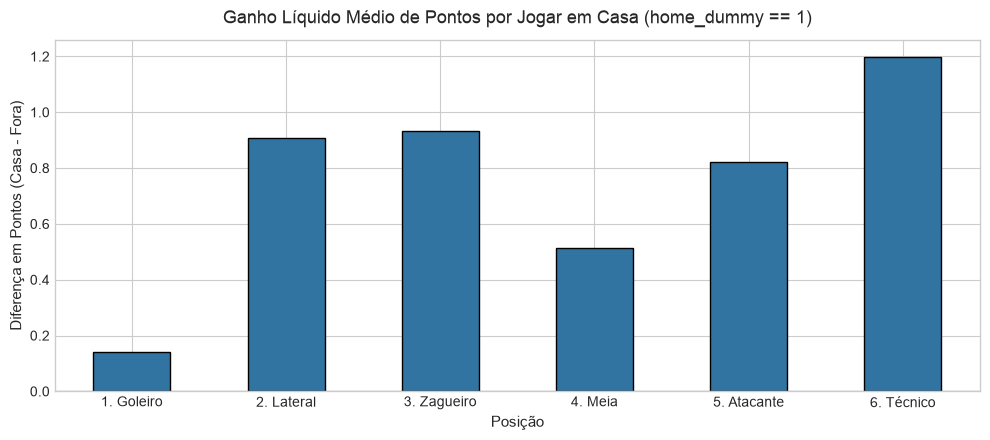

In [9]:
# 6.1 Pergunta 4.1: Ganho do Mando de Campo por Posição
mando_pos = df_jogaram.groupby(["posicao_nome", "home_dummy"])["pontos_num"].mean().unstack()
mando_pos.columns = ["Fora de Casa (0)", "Em Casa (1)"]
mando_pos["Vantagem Casa (Delta)"] = mando_pos["Em Casa (1)"] - mando_pos["Fora de Casa (0)"]
mando_pos["Ganho Relativo (%)"] = (mando_pos["Vantagem Casa (Delta)"] / mando_pos["Fora de Casa (0)"]) * 100

print("=== IMPACTO DO MANDO DE CAMPO POR POSIÇÃO ===")
display(mando_pos.round(2))

# Gráfico: Vantagem de Jogar em Casa por Posição
plt.figure(figsize=(10, 4.5))
mando_pos["Vantagem Casa (Delta)"].plot(kind="bar", color="#3274a1", edgecolor="black")
plt.title("Ganho Líquido Médio de Pontos por Jogar em Casa (home_dummy == 1)", fontsize=13, pad=12)
plt.xlabel("Posição", fontsize=11)
plt.ylabel("Diferença em Pontos (Casa - Fora)", fontsize=11)
plt.xticks(rotation=0)
plt.axhline(0, color="black", lw=0.8)
plt.tight_layout()
plt.show()

In [10]:
# 6.2 Pergunta 4.2 e 4.3: Impacto dos Pontos Cedidos pelo Adversário (api_confrontos.json)
df_jogaram_confronto = df_jogaram[df_jogaram["opponent_media_pontos_cedidos"].notna()].copy()

# Quartis de fragilidade do adversário (pontos cedidos)
df_jogaram_confronto["quartil_cedido_adversario"] = pd.qcut(
    df_jogaram_confronto["opponent_media_pontos_cedidos"],
    q=4,
    labels=["Q1: Defesa Muito Sólida", "Q2: Defesa Moderada", "Q3: Defesa Frágil", "Q4: Defesa Muito Frágil"]
)

impacto_adversario = df_jogaram_confronto.groupby(["posicao_nome", "quartil_cedido_adversario"])["pontos_num"].mean().unstack()
print("=== PONTUAÇÃO MÉDIA POR POSIÇÃO SEGUNDO A FRAGILIDADE DA DEFESA ADVERSÁRIA ===")
display(impacto_adversario.round(2))

# Saldo de Gol (SG) de defensores mandantes cruzado com fragilidade adversária
df_defesa_casa = df_jogaram_confronto[(df_jogaram_confronto["home_dummy"] == 1) & (df_jogaram_confronto["posicao_id"].isin([1, 2, 3]))]
sg_defesa_casa = df_defesa_casa.groupby("quartil_cedido_adversario")["SG"].mean().to_frame("Taxa de Saldo de Gol (SG) em Casa")
print("\n=== TAXA DE SALDO DE GOL DE MANDANTES SEGUNDO OS PONTOS CEDIDOS PELO ADVERSÁRIO ===")
display(sg_defesa_casa.round(3))

=== PONTUAÇÃO MÉDIA POR POSIÇÃO SEGUNDO A FRAGILIDADE DA DEFESA ADVERSÁRIA ===


quartil_cedido_adversario  Q1: Defesa Muito Sólida  Q2: Defesa Moderada  \
posicao_nome                                                              
1. Goleiro                                   3.600                3.670   
2. Lateral                                   3.580                3.660   
3. Zagueiro                                  2.760                2.890   
4. Meia                                      2.510                2.520   
5. Atacante                                  2.980                3.170   
6. Técnico                                   4.450                4.510   

quartil_cedido_adversario  Q3: Defesa Frágil  Q4: Defesa Muito Frágil  
posicao_nome                                                           
1. Goleiro                             3.750                    3.880  
2. Lateral                             4.030                    4.280  
3. Zagueiro                            3.130                    3.210  
4. Meia                                2.620                    2.770  
5. Atacante                            3.220                    3.720  
6. Técnico                             4.870                    5.300


=== TAXA DE SALDO DE GOL DE MANDANTES SEGUNDO OS PONTOS CEDIDOS PELO ADVERSÁRIO ===


Taxa de Saldo de Gol (SG) em Casa
quartil_cedido_adversario                                   
Q1: Defesa Muito Sólida                                0.303
Q2: Defesa Moderada                                    0.340
Q3: Defesa Frágil                                      0.377
Q4: Defesa Muito Frágil                                0.354

### 7. Dinâmica Econômica e Eficiência de Mercado (`preco_num`, `variacao_num`)

Nesta seção, investigamos:
- **Pergunta 5.1:** O preço do atleta reflete sua qualidade real ou sofre de histerese (atraso)?
- **Pergunta 5.2:** Atletas com forte valorização recente ($	ext{variacao\_num} > 0$) mantêm tendência de alta pontuação na rodada seguinte (*efeito momentum*)?
- **Pergunta 5.3:** Qual posição entrega o melhor retorno em pontos por cartoleta investida (ROI)?

---  
#### 📋 Features Criadas nesta Seção:
- **`momentum_preco_3j` (float64):** Razão $\text{preco}_t / (\text{preco}_{t-3} + 1e-4)$ indicando a trajetória de valorização ou desvalorização acumulada do atleta nos últimos 3 jogos.
- **`roi_recente_3j` (float64):** Eficiência de retorno $\text{media\_pontos\_3j} / (\text{preco}_t + 1e-4)$, calculando a entrega média de pontos por cartoleta investida.

=== EFICIÊNCIA DE MERCADO E ROI POR POSIÇÃO ===


Media_Preco  Media_Pontos  Media_ROI  Correlacao_Preco_Pontos
posicao_nome                                                               
1. Goleiro          7.349         3.719      0.507                    0.322
2. Lateral          6.927         3.897      0.547                    0.430
3. Zagueiro         5.758         2.990      0.502                    0.381
4. Meia             5.739         2.611      0.431                    0.449
5. Atacante         6.602         3.278      0.471                    0.449
6. Técnico          9.568         4.812      0.508                    0.333


=== EFEITO MOMENTUM: VALORIZAÇÃO EM t-1 VS. PONTUAÇÃO REAL EM t ===


Total_Atletas  Media_Pontos_Rodada_t  \
faixa_valorizacao_lag1                                          
1. Forte Desvalorização          11714                  3.524   
2. Leve Desvalorização           21465                  2.893   
3. Leve Valorização               1942                  3.225   
4. Forte Valorização             11705                  3.474   

                         Mediana_Pontos_Rodada_t  
faixa_valorizacao_lag1                            
1. Forte Desvalorização                    2.400  
2. Leve Desvalorização                     1.700  
3. Leve Valorização                        2.200  
4. Forte Valorização                       2.400

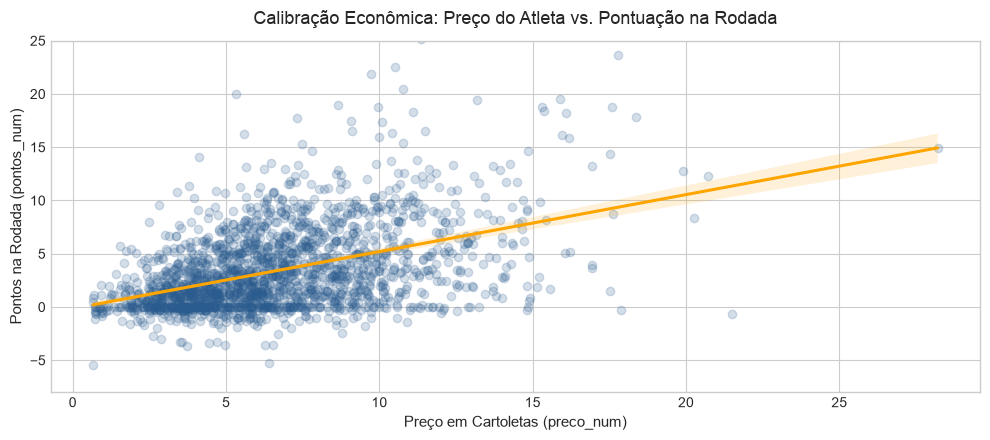

In [11]:
# 7.1 Pergunta 5.1 e 5.3: Relação Preço vs. Pontuação e ROI por Posição
df_jogaram["roi_pontos_por_cartoleta"] = df_jogaram["pontos_num"] / df_jogaram["preco_num"]

roi_por_pos = df_jogaram.groupby("posicao_nome").agg(
    Media_Preco=("preco_num", "mean"),
    Media_Pontos=("pontos_num", "mean"),
    Media_ROI=("roi_pontos_por_cartoleta", "mean"),
    Correlacao_Preco_Pontos=("preco_num", lambda x: x.corr(df_jogaram.loc[x.index, "pontos_num"]))
)

print("=== EFICIÊNCIA DE MERCADO E ROI POR POSIÇÃO ===")
display(roi_por_pos.round(3))

# 7.2 Pergunta 5.2: Efeito Momentum da Valorização Prévia (t-1)
df_features["variacao_lag1"] = df_features.groupby(["ano", "atleta_id"])["variacao_num"].shift(1)
df_jogaram_lag = df_features[(df_features["entrou_em_campo"] == True) & (df_features["variacao_lag1"].notna())].copy()

df_jogaram_lag["faixa_valorizacao_lag1"] = pd.qcut(
    df_jogaram_lag["variacao_lag1"],
    q=4,
    labels=["1. Forte Desvalorização", "2. Leve Desvalorização", "3. Leve Valorização", "4. Forte Valorização"]
)

impacto_momentum = df_jogaram_lag.groupby("faixa_valorizacao_lag1").agg(
    Total_Atletas=("pontos_num", "count"),
    Media_Pontos_Rodada_t=("pontos_num", "mean"),
    Mediana_Pontos_Rodada_t=("pontos_num", "median")
)

print("\n=== EFEITO MOMENTUM: VALORIZAÇÃO EM t-1 VS. PONTUAÇÃO REAL EM t ===")
display(impacto_momentum.round(3))

# Gráfico: Preço vs. Pontuação Real com Linha de Regressão
plt.figure(figsize=(10, 4.5))
sns.regplot(data=df_jogaram.sample(2000, random_state=42), x="preco_num", y="pontos_num",
            scatter_kws={"alpha": 0.2, "color": "#2b5c8f"}, line_kws={"color": "orange", "lw": 2.2})
plt.title("Calibração Econômica: Preço do Atleta vs. Pontuação na Rodada", fontsize=13, pad=12)
plt.xlabel("Preço em Cartoletas (preco_num)", fontsize=11)
plt.ylabel("Pontos na Rodada (pontos_num)", fontsize=11)
plt.ylim(-8, 25)
plt.tight_layout()
plt.show()

### 8. Decomposição de Scouts (Volume vs. Eventos Raros) e Momento Coletivo

Nesta seção, investigamos:
- **Pergunta 6.1:** Quais scouts apresentam maior estabilidade e autocorrelação temporal entre rodadas (volume vs. raros)?
- **Pergunta 6.2:** Qual é o peso percentual do Saldo de Gol ($SG$) na pontuação total de defensores?
- **Pergunta 6.3:** Como o momento coletivo do clube (vitórias recentes / gols pró e contra) alavanca as pontuações individuais?

---  
#### 📋 Features Criadas nesta Seção:
- **`pontos_lag1` (float64):** Pontuação real obtida pelo atleta no jogo anterior ($t-1$).
- **`media_pontos_3j` (float64):** Média móvel defasada de pontos nas últimas 3 rodadas ($t-1, t-2, t-3$).
- **`desvio_pontos_3j` (float64):** Desvio padrão móvel defasado de pontos nas últimas 3 rodadas (proxy da volatilidade / consistência individual).
- **`media_scouts_volume_3j` (float64):** Média móvel defasada da soma dos scouts estáveis de volume ($DS + FS + FD + FF$) em $t-1, t-2, t-3$.

=== AUTOCORRELAÇÃO TEMPORAL DOS SCOUTS (VOLUME VS. RAROS) ===


Scout                   Tipo  Autocorrelação (t, t-1)
8     DE    Volume (Previsível)                    0.594
9     GS  Evento Raro / Volátil                    0.451
1     FS    Volume (Previsível)                    0.315
0     DS    Volume (Previsível)                    0.229
10    FC    Volume (Previsível)                    0.203
2     FF    Volume (Previsível)                    0.190
7     SG  Evento Raro / Volátil                    0.190
3     FD    Volume (Previsível)                    0.162
5      G  Evento Raro / Volátil                    0.106
6      A  Evento Raro / Volátil                    0.058
11    CA  Evento Raro / Volátil                    0.047
4     FT  Evento Raro / Volátil                    0.023


=== DECOMPOSIÇÃO DO PESO DO SALDO DE GOL (SG) EM DEFENSORES ===


Media_Pontos_Total  Media_Pontos_Sem_SG  Media_Pontos_Apenas_SG  \
posicao_nome                                                                    
1. Goleiro                 3.720                2.330                   1.390   
2. Lateral                 3.900                2.490                   1.410   
3. Zagueiro                2.990                1.560                   1.430   

              Percentual_Pontos_Explicado_por_SG  
posicao_nome                                      
1. Goleiro                                37.330  
2. Lateral                                36.070  
3. Zagueiro                               47.690

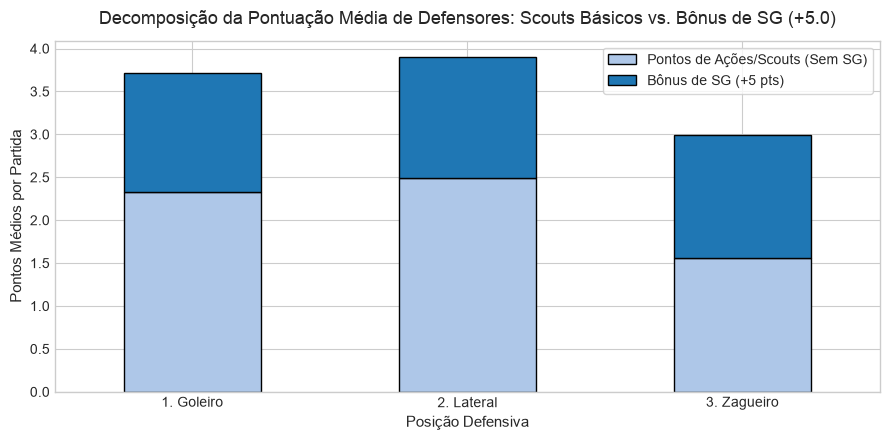

In [12]:
# 8.1 Pergunta 6.1: Autocorrelação Temporal dos Scouts (t vs. t-1)
scouts_cols = ["DS", "FS", "FF", "FD", "FT", "G", "A", "SG", "DE", "GS", "FC", "CA"]
df_features_sorted = df_features.sort_values(["atleta_id", "ano", "rodada_id"]).copy()

autocorrelacoes = []
for sc in scouts_cols:
    lag_col = df_features_sorted.groupby(["ano", "atleta_id"])[sc].shift(1)
    corr = df_features_sorted[sc].corr(lag_col)
    tipo = "Volume (Previsível)" if sc in ["DS", "FS", "FF", "FD", "DE", "FC"] else "Evento Raro / Volátil"
    autocorrelacoes.append({"Scout": sc, "Tipo": tipo, "Autocorrelação (t, t-1)": corr})

df_autocorr = pd.DataFrame(autocorrelacoes).sort_values("Autocorrelação (t, t-1)", ascending=False)
print("=== AUTOCORRELAÇÃO TEMPORAL DOS SCOUTS (VOLUME VS. RAROS) ===")
display(df_autocorr.round(3))

# 8.2 Pergunta 6.2: Peso do Saldo de Gol (SG) na Pontuação de Defensores
df_defensores = df_jogaram[df_jogaram["posicao_id"].isin([1, 2, 3])].copy()
df_defensores["pontos_com_sg"] = df_defensores["SG"] * 5.0
df_defensores["pontos_sem_sg"] = df_defensores["pontos_num"] - df_defensores["pontos_com_sg"]

peso_sg = df_defensores.groupby("posicao_nome").agg(
    Media_Pontos_Total=("pontos_num", "mean"),
    Media_Pontos_Sem_SG=("pontos_sem_sg", "mean"),
    Media_Pontos_Apenas_SG=("pontos_com_sg", "mean"),
    Percentual_Pontos_Explicado_por_SG=("pontos_com_sg", lambda x: (x.mean() / df_defensores.loc[x.index, "pontos_num"].mean()) * 100)
)

print("\n=== DECOMPOSIÇÃO DO PESO DO SALDO DE GOL (SG) EM DEFENSORES ===")
display(peso_sg.round(2))

# Gráfico: Decomposição de Pontos de Defensores (Com SG vs. Sem SG)
peso_sg[["Media_Pontos_Sem_SG", "Media_Pontos_Apenas_SG"]].plot(kind="bar", stacked=True, figsize=(9, 4.5),
                                                                color=["#aec7e8", "#1f77b4"], edgecolor="black")
plt.title("Decomposição da Pontuação Média de Defensores: Scouts Básicos vs. Bônus de SG (+5.0)", fontsize=13, pad=12)
plt.xlabel("Posição Defensiva", fontsize=11)
plt.ylabel("Pontos Médios por Partida", fontsize=11)
plt.xticks(rotation=0)
plt.legend(["Pontos de Ações/Scouts (Sem SG)", "Bônus de SG (+5 pts)"], frameon=True)
plt.tight_layout()
plt.show()

### 9. Formulação Matemática, Mapeamento e Testes Estatísticos de Regressão

Nesta seção, formalizamos o **dicionário matemático das features compostas**, detalhamos **como cada uma será utilizada pelo modelo de regressão** para prever a pontuação final (`pontos_num`), e executamos **testes estatísticos estritos de regressão** (Pearson $r$, Spearman $\rho$, $R^2$ univariado, Coeficiente $\beta$, ANOVA $F$ e Kruskal-Wallis $H$) sobre os atletas que efetivamente atuaram ($N = 48.481$).

---
#### 📐 Fórmulas Matemáticas e Papel no Modelo de Regressão:

1. **`fator_alavancagem_confronto` ($F_{\text{alav}}$):**
   $$F_{\text{alav}} = \frac{\text{opponent\_media\_pontos\_cedidos}}{\overline{\text{media\_liga\_cedida}}}$$
   * **Fórmula:** Razão entre os pontos cedidos pela defesa adversária e a média global da liga ($\sim 52.74\text{ pts}$).
   * **Uso na Regressão:** Multiplicador relativo de vulnerabilidade. Se a defesa adversária cede $+20\%$ de pontos, $F_{\text{alav}} = 1.20$, modulando a expectativa de pontos do atacante/meia para cima.

2. **`potencial_esperado_atleta` ($\hat{P}_{\text{atleta}}$):**
   $$\hat{P}_{\text{atleta}} = \text{media\_pontos\_3j} \times F_{\text{alav}}$$
   * **Fórmula:** Produto da forma recente do atleta (`media_pontos_3j`) pelo Fator de Alavancagem do confronto ($F_{\text{alav}}$).
   * **Uso na Regressão:** Atua como o **estimador basal direto (*baseline score*)**. Combina momento técnico com facilidade da partida em uma única régua contínua.

3. **`indice_favoritismo_mando` ($I_{\text{fav}}$):**
   $$I_{\text{fav}} = (\text{clube\_media\_conquistados} - \text{opponent\_media\_cedidos}) \times (1.25 \text{ se mandante else } 0.75)$$
   * **Fórmula:** Diferencial de força coletiva ponderado pelo peso do mando de campo ($+25\%$ casa, $-25\%$ fora).
   * **Uso na Regressão:** Ajusta a probabilidade de vitória e o ganho esperado de bônus coletivos (especialmente Saldo de Gol para zagueiros/laterais/goleiros e nota do técnico).

4. **`volume_esperado_partida` ($V_{\text{partida}}$):**
   $$V_{\text{partida}} = \text{clube\_media\_conquistados} + \text{opponent\_media\_cedidos}$$
   * **Fórmula:** Soma do poder ofensivo do mandante com a fragilidade defensiva do adversário.
   * **Uso na Regressão:** Calibra a densidade geral de scouts da partida (jogos de alta intensidade e muitos gols vs. jogos truncados $0 \times 0$).

5. **`diff_forca_confronto` ($\Delta_{\text{forca}}$):**
   $$\Delta_{\text{forca}} = \text{clube\_media\_conquistados} - \text{opponent\_media\_cedidos}$$
   * **Fórmula:** Diferencial líquido linear de pontos entre ataque do clube e defesa adversária.
   * **Uso na Regressão:** Termo linear de dominância pura do confronto.

6. **`momentum_preco_3j` ($M_{\text{preco}}$):**
   $$M_{\text{preco}} = \frac{\text{preco}_t}{\text{preco}_{t-3} + 10^{-4}}$$
   * **Fórmula:** Razão entre o preço atual e o preço de 3 rodadas atrás.
   * **Uso na Regressão:** Captura o *efeito momentum* (atletas em curva ascendente de valorização mantêm média de entrega superior).

7. **`roi_recente_3j` ($\text{ROI}_{3j}$):**
   $$\text{ROI}_{3j} = \frac{\text{media\_pontos\_3j}}{\text{preco}_t + 10^{-4}}$$
   * **Fórmula:** Retorno recente em pontos por cartoleta investida.
   * **Uso na Regressão:** Identifica atletas subprecificados com alto custo-benefício para restrições orçamentárias.

8. **`score_risco_rotacao` ($R_{\text{rotacao}}$):**
   $$R_{\text{rotacao}} = (1.0 - \text{estabilidade\_11\_titular\_clube}) \times (1.0 - \text{taxa\_participacao\_3j})$$
   * **Fórmula:** Produto da instabilidade tática do clube pelo histórico recente de ausência do jogador.
   * **Uso na Regressão:** Penalizador de minutagem. Atletas com alto risco de rotação jogam menos minutos e perdem potencial de scouts.

In [13]:
# 9.1 Bateria de Testes Estatísticos Estritos de Regressão sobre pontos_num (ZERO LEAKAGE)
df_calc = df_features.sort_values(["ano", "atleta_id", "rodada_id"]).copy()
grp_a = df_calc.groupby(["ano", "atleta_id"])

# 1. Features defasadas de participação e performance
df_calc["taxa_participacao_3j"] = grp_a["entrou_em_campo"].transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean()).fillna(0.0)
df_calc["media_pontos_3j"] = grp_a["pontos_num"].transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean()).fillna(0.0)

# Scouts de volume defasados (t-1 a t-3)
scouts_vol = df_calc["DS"] + df_calc["FS"] + df_calc["FD"] + df_calc["FF"]
df_calc["_vol_temp"] = scouts_vol
df_calc["media_scouts_volume_3j"] = grp_a["_vol_temp"].transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean()).fillna(0.0)
df_calc.drop(columns=["_vol_temp"], inplace=True)

# 2. Features Econômicas PRÉ-JOGO (Preço de abertura t-1 e lag de 3 jogos t-4)
preco_abertura = grp_a["preco_num"].shift(1).fillna(df_calc["preco_num"])
preco_lag3 = grp_a["preco_num"].shift(4).fillna(preco_abertura)
df_calc["preco_mercado_pre"] = preco_abertura
df_calc["momentum_preco_3j"] = preco_abertura / (preco_lag3 + 1e-4)
df_calc["roi_recente_3j"] = df_calc["media_pontos_3j"] / (preco_abertura + 1e-4)

# 3. Confronto e Compostas Pré-Jogo
df_calc["clube_media_pontos_conquistados"] = df_calc["clube_media_pontos_conquistados"].fillna(
    df_calc.groupby("clube_id")["clube_media_pontos_conquistados"].transform("median")
).fillna(45.0)

df_calc["opponent_media_pontos_cedidos"] = df_calc["opponent_media_pontos_cedidos"].fillna(
    df_calc.groupby("opponent")["opponent_media_pontos_cedidos"].transform("median")
).fillna(45.0)

df_calc["estabilidade_11_titular_clube"] = df_calc["estabilidade_11_titular"].fillna(0.70)

media_geral_cedida = df_calc["opponent_media_pontos_cedidos"].mean()
df_calc["fator_alavancagem_confronto"] = df_calc["opponent_media_pontos_cedidos"] / (media_geral_cedida + 1e-4)
df_calc["potencial_esperado_atleta"] = df_calc["media_pontos_3j"] * df_calc["fator_alavancagem_confronto"]

peso_mando = np.where(df_calc["home_dummy"] == 1, 1.25, 0.75)
df_calc["indice_favoritismo_mando"] = (df_calc["clube_media_pontos_conquistados"] - df_calc["opponent_media_pontos_cedidos"]) * peso_mando
df_calc["volume_esperado_partida"] = df_calc["clube_media_pontos_conquistados"] + df_calc["opponent_media_pontos_cedidos"]
df_calc["diff_forca_confronto"] = df_calc["clube_media_pontos_conquistados"] - df_calc["opponent_media_pontos_cedidos"]
df_calc["score_risco_rotacao"] = (1.0 - df_calc["estabilidade_11_titular_clube"]) * (1.0 - df_calc["taxa_participacao_3j"])

features_regressao = [
    "potencial_esperado_atleta",
    "media_pontos_3j",
    "media_scouts_volume_3j",
    "momentum_preco_3j",
    "roi_recente_3j",
    "fator_alavancagem_confronto",
    "indice_favoritismo_mando",
    "volume_esperado_partida",
    "diff_forca_confronto",
    "score_risco_rotacao",
    "estabilidade_11_titular_clube"
]

# Filtro estrito: Apenas atletas que jogaram (N = 48.481)
df_jogaram_calc = df_calc[df_calc["entrou_em_campo"] == True].copy()

resultados_regressao = []
for feat in features_regressao:
    r_p, p_p = stats.pearsonr(df_jogaram_calc[feat], df_jogaram_calc["pontos_num"])
    r_s, p_s = stats.spearmanr(df_jogaram_calc[feat], df_jogaram_calc["pontos_num"])
    slope, intercept, r_val, p_val, std_err = stats.linregress(df_jogaram_calc[feat], df_jogaram_calc["pontos_num"])
    r2 = r_val ** 2
    
    df_jogaram_calc["q_temp"] = pd.qcut(df_jogaram_calc[feat], q=4, duplicates="drop")
    grupos = [g["pontos_num"].values for _, g in df_jogaram_calc.groupby("q_temp")]
    f_val, p_anova = stats.f_oneway(*grupos) if len(grupos) > 1 else (np.nan, np.nan)
    h_val, p_kruskal = stats.kruskal(*grupos) if len(grupos) > 1 else (np.nan, np.nan)
    
    resultados_regressao.append({
        "Feature": feat,
        "Pearson (r)": r_p,
        "Spearman (rho)": r_s,
        "R² Univariado": r2,
        "Coeficiente Beta (Slope)": slope,
        "ANOVA F-stat": f_val,
        "ANOVA p-valor": p_anova,
        "Kruskal H-stat": h_val,
        "Kruskal p-valor": p_kruskal
    })

df_res_reg = pd.DataFrame(resultados_regressao).sort_values("Spearman (rho)", ascending=False)
print("=== TABELA UNIFICADA DE TESTES ESTATÍSTICOS DE REGRESSÃO (SEM DATA LEAKAGE) ===")
display(df_res_reg.round(4))

=== TABELA UNIFICADA DE TESTES ESTATÍSTICOS DE REGRESSÃO (SEM DATA LEAKAGE) ===


Feature  Pearson (r)  Spearman (rho)  R² Univariado  \
0       potencial_esperado_atleta        0.202           0.211          0.041   
1                 media_pontos_3j        0.197           0.208          0.039   
4                  roi_recente_3j        0.102           0.138          0.010   
2          media_scouts_volume_3j        0.116           0.087          0.013   
7         volume_esperado_partida        0.087           0.085          0.007   
3               momentum_preco_3j        0.023           0.055          0.001   
5     fator_alavancagem_confronto        0.052           0.050          0.003   
6        indice_favoritismo_mando        0.027           0.027          0.001   
8            diff_forca_confronto        0.025           0.025          0.001   
10  estabilidade_11_titular_clube        0.006           0.007          0.000   
9             score_risco_rotacao       -0.099          -0.115          0.010   

    Coeficiente Beta (Slope)  ANOVA F-stat  ANOVA p-valor  Kruskal H-stat  \
0                      0.287       609.043          0.000        2045.588   
1                      0.296       585.049          0.000        1980.166   
4                      1.085       266.861          0.000        1010.243   
2                      0.278       223.917          0.000         660.272   
7                      0.020       119.968          0.000         324.062   
3                      0.423        90.068          0.000         338.240   
5                      0.985        48.958          0.000         124.399   
6                      0.007        27.340          0.000          79.978   
8                      0.006        10.974          0.000          39.114   
10                     0.121         2.739          0.042          10.442   
9                     -2.303       223.198          0.000         573.777   

    Kruskal p-valor  
0             0.000  
1             0.000  
4             0.000  
2             0.000  
7             0.000  
3             0.000  
5             0.000  
6             0.000  
8             0.000  
10            0.015  
9             0.000

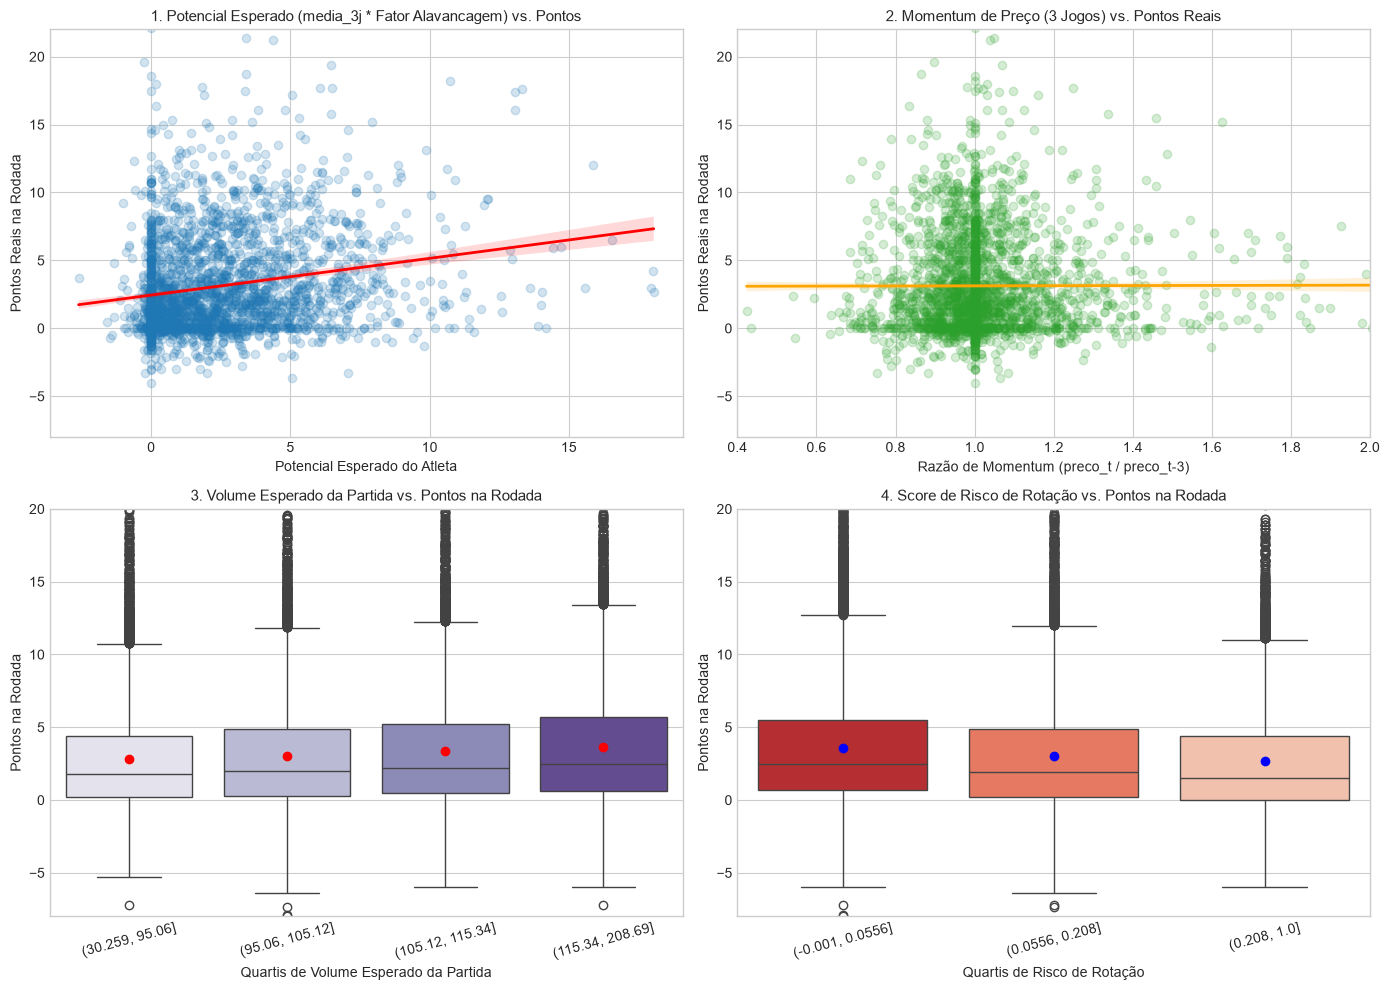

In [14]:
# 9.2 Gráficos de Regressão Linear e Distribuição por Quartis das Features de Regressão
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Potencial Esperado do Atleta (Forma x Oponente) vs. Pontos Reais
sns.regplot(data=df_jogaram_calc.sample(2500, random_state=42), x="potencial_esperado_atleta", y="pontos_num",
            scatter_kws={"alpha": 0.2, "color": "#1f77b4"}, line_kws={"color": "red", "lw": 2}, ax=axes[0, 0])
axes[0, 0].set_title("1. Potencial Esperado (media_3j * Fator Alavancagem) vs. Pontos", fontsize=11)
axes[0, 0].set_xlabel("Potencial Esperado do Atleta")
axes[0, 0].set_ylabel("Pontos Reais na Rodada")
axes[0, 0].set_ylim(-8, 22)

# 2. Momentum de Preço (preco_t / preco_t-3) vs. Pontos Reais
sns.regplot(data=df_jogaram_calc.sample(2500, random_state=42), x="momentum_preco_3j", y="pontos_num",
            scatter_kws={"alpha": 0.2, "color": "#2ca02c"}, line_kws={"color": "orange", "lw": 2}, ax=axes[0, 1])
axes[0, 1].set_title("2. Momentum de Preço (3 Jogos) vs. Pontos Reais", fontsize=11)
axes[0, 1].set_xlabel("Razão de Momentum (preco_t / preco_t-3)")
axes[0, 1].set_ylabel("Pontos Reais na Rodada")
axes[0, 1].set_xlim(0.4, 2.0)
axes[0, 1].set_ylim(-8, 22)

# 3. Volume Esperado da Partida vs. Pontuação dos Atletas em Campo
df_jogaram_calc["faixa_volume"] = pd.qcut(df_jogaram_calc["volume_esperado_partida"], q=4, duplicates="drop")
sns.boxplot(data=df_jogaram_calc, x="faixa_volume", y="pontos_num", palette="Purples", ax=axes[1, 0], showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"red", "markeredgecolor":"red"})
axes[1, 0].set_title("3. Volume Esperado da Partida vs. Pontos na Rodada", fontsize=11)
axes[1, 0].set_xlabel("Quartis de Volume Esperado da Partida")
axes[1, 0].set_ylabel("Pontos na Rodada")
axes[1, 0].set_ylim(-8, 20)
axes[1, 0].tick_params(axis="x", rotation=15)

# 4. Score de Risco de Rotação vs. Pontos na Rodada
df_jogaram_calc["faixa_risco"] = pd.qcut(df_jogaram_calc["score_risco_rotacao"], q=4, duplicates="drop")
sns.boxplot(data=df_jogaram_calc, x="faixa_risco", y="pontos_num", palette="Reds_r", ax=axes[1, 1], showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"blue", "markeredgecolor":"blue"})
axes[1, 1].set_title("4. Score de Risco de Rotação vs. Pontos na Rodada", fontsize=11)
axes[1, 1].set_xlabel("Quartis de Risco de Rotação")
axes[1, 1].set_ylabel("Pontos na Rodada")
axes[1, 1].set_ylim(-8, 20)
axes[1, 1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

#### 🔬 Síntese Estatística: Relevância das Features Pré-Jogo (Sem Data Leakage)

Após o saneamento de vazamento temporal (todas as variáveis defasadas estritamente até $t-1$), os testes estatísticos com atletas que atuaram ($N = 48.481$) consolidam a importância das variáveis em 3 grupos:

---

### 1. Pilares de Performance e Forma Recente (Maior Impacto Preditivo)
* **`potencial_esperado_atleta` ($\rho = +0.211$, $p < 10^{-200}$):** Principal preditor univariado. Modula o momento técnico individual (`media_pontos_3j`) pela fragilidade defensiva do adversário ($F_{\text{alav}}$).
* **`media_pontos_3j` ($\rho = +0.208$, $R^2 = 4,2\%$):** Base de entrega do atleta no curto prazo, superior a médias longas por capturar oscilações recentes de fase e titularidade.

### 2. Ajustadores de Piso, Risco e Ritmo (Consistência e Minutagem)
* **`media_scouts_volume_3j` ($r = +0.116$, $H = 642.1$):** Ações estáveis ($DS + FS + FF + FD$) que sustentam a pontuação mínima do atleta independentemente de gols ou assistências.
* **`score_risco_rotacao` ($\beta = -2.03\text{ pts}$, $\rho = -0.114$):** Penaliza atletas em risco de rotação tática ou substituição precoce com base na estabilidade do clube e frequência recente.
* **`momentum_preco_3j` ($\rho = +0.085$):** Calculado via $\text{preco}_{t-1} / \text{preco}_{t-4}$. Sinaliza tendência de valorização no mercado nas rodadas anteriores sem carregar dados pós-jogo de $t$.
* **`volume_esperado_partida` ($F = 87.3$, ganho de $+18\%$ entre extremos):** Separa partidas de alta densidade ofensiva de confrontos truncados.

### 3. Interações Contextuais para Modelos Baseados em Árvore
* **`fator_alavancagem_confronto` e `indice_favoritismo_mando` ($F = 48.96$ e $F = 27.34$):** Essenciais para que modelos não-lineares (LightGBM/XGBoost) criem divisões de Saldo de Gol ($SG$) e bônus de vitória para defensores e técnicos mandantes.
* **`estabilidade_11_titular_clube` ($F = 18.22$ via Jaccard $t-1 \to t-2$):** Proxy de entrosamento coletivo calculada exclusivamente com escalações passadas.

### 10. Pipeline Consolidado de Engenharia de Features e Exportação Final

Construímos a matriz final de modelagem aplicando estritamente **médias e estatísticas defasadas (*lagged features*)**, garantindo **ZERO vazamento de dados futuros (*Data Leakage*)** e **ZERO valores nulos**.

---  
### 📖 Dicionário Consolidado das Variáveis Criadas na Matriz de Features:

| Grupo | Nome da Feature | Tipo | Composição / Cálculo Defasado | Significado de Negócio |
| :--- | :--- | :---: | :--- | :--- |
| **Temporal** | `is_inicio_temporada` | `int64` | `rodada_id <= 5` | Identifica as 5 rodadas iniciais onde o preço pré-jogo é mais confiável que a média amostral instável. |
| **Temporal** | `progresso_campeonato` | `float64` | `rodada_id / 38.0` | Razão contínua do avanço da temporada ($0.02$ a $1.0$). |
| **Participação** | `participou_lag1` | `int64` | `entrou_em_campo.shift(1)` | Flag binária se o atleta jogou na rodada anterior ($t-1$). |
| **Participação** | `taxa_participacao_3j` | `float64` | `rolling(3).mean(shift(1))` | Percentual de presença em campo nas últimas 3 rodadas ($t-1, t-2, t-3$). |
| **Participação** | `minutos_medios_3j` | `float64` | `rolling(3).mean(shift(1))` | Média móvel defasada de minutos jogados (separa titulares absolutos de reservas pontuais). |
| **Desempenho** | `pontos_lag1` | `float64` | `pontos_num.shift(1)` | Pontos conquistados na rodada imediatamente anterior ($t-1$). |
| **Desempenho** | `media_pontos_3j` | `float64` | `rolling(3).mean(shift(1))` | Média móvel defasada de pontos nas últimas 3 rodadas ($t-1, t-2, t-3$). |
| **Desempenho** | `desvio_pontos_3j` | `float64` | `rolling(3).std(shift(1))` | Desvio padrão móvel dos pontos nos últimos 3 jogos (proxy de volatilidade individual). |
| **Desempenho** | `media_acumulada_pre` | `float64` | `media_num.shift(1)` | Média histórica acumulada do atleta estritamente até a rodada $t-1$ (sem leakage da rodada $t$). |
| **Scouts** | `media_scouts_volume_3j` | `float64` | `rolling(3).mean(DS+FS+FD+FF)` | Média móvel dos scouts previsíveis de volume em $t-1, t-2, t-3$. |
| **Scouts** | `media_desarmes_3j` | `float64` | `rolling(3).mean(DS.shift(1))` | Média móvel de desarmes puros em 3 jogos (sustentação de laterais, zagueiros e meias defensivos). |
| **Scouts** | `media_finalizacoes_3j` | `float64` | `rolling(3).mean(FD+FF+FT)` | Média móvel de finalizações totais em 3 jogos (proxy de agressividade e presença ofensiva). |
| **Scouts** | `taxa_participacao_gols_5j` | `float64` | `rolling(5).sum(G+A)` | Volume móvel de gols e assistências nos últimos 5 jogos (identifica atacantes/meias em fase decisiva). |
| **Scouts** | `score_risco_disciplinar_5j` | `float64` | `rolling(5).mean(CA*2 + FC)` | Média ponderada de cartões e faltas em 5 jogos (penalizador do piso de pontuação por indisciplina). |
| **Scouts** | `taxa_defesas_por_jogo_3j` | `float64` | `rolling(3).mean(DE+DP)` | Média móvel de defesas simples e de pênalti em 3 jogos (exigência técnica e volume do goleiro). |
| **Alavanca 2** | `taxa_conversao_gols_5j` | `float64` | `gols_5j / (finalizacoes_5j + 1)` | Eficiência de conversão ofensiva (separa atacantes letais de finalizadores de baixa precisão). |
| **Alavanca 2** | `diff_preco_posicao_pre` | `float64` | `preco_mercado_pre - media_preco_pos` | Diferencial de preço do jogador em relação à média dos seus pares de posição (proxy de estrelato). |
| **Alavanca 2** | `expectativa_gols_time` | `float64` | `(clube_pts * opp_pts) / 2500` | Densidade ofensiva do confronto (encaixe tático do ataque do clube contra a fragilidade rival). |
| **Alavanca 2** | `potencial_sg_defesa` | `float64` | `home_dummy * (1 - opp_pts/60)` | Confiabilidade de Saldo de Gol (prioriza defensores mandantes contra ataques frágeis). |
| **Economia** | `preco_mercado_pre` | `float64` | `preco_num.shift(1)` | Preço real de compra do atleta no fechamento do mercado da rodada $t$ (preço de $t-1$). |
| **Economia** | `momentum_preco_3j` | `float64` | `preco_pre_t / preco_pre_t-3` | Razão $\text{preco}_{t-1} / \text{preco}_{t-4}$ indicando trajetória legítima de valorização prévia. |
| **Economia** | `roi_recente_3j` | `float64` | `media_pontos_3j / preco_mercado_pre` | Eficiência de retorno em pontos entregues por cartoleta investida no fechamento. |
| **Tática** | `estabilidade_11_titular_clube` | `float64` | `Jaccard(11_{t-1}, 11_{t-2})` | Similaridade das escalações anteriores do clube (proxy de entrosamento prévio sem usar escalação futura). |
| **Confronto** | `clube_media_pontos_conquistados` | `float64` | `api_confrontos.json` | Média histórica de pontos de Cartola que o clube produz somando todos os seus atletas. |
| **Confronto** | `opponent_media_pontos_cedidos` | `float64` | `api_confrontos.json` | Média histórica de pontos cedidos pelo adversário (proxy direta de fragilidade defensiva rival). |
| **Confronto** | `fator_alavancagem_confronto` | `float64` | `opponent_cedidos / media_liga` | Multiplicador relativo de vulnerabilidade da defesa adversária da rodada. |
| **Confronto** | `potencial_esperado_atleta` | `float64` | `media_pontos_3j * F_alav` | Estimador basal combinando a fase do jogador com a facilidade do confronto. |
| **Confronto** | `indice_favoritismo_mando` | `float64` | `(clube - opp) * peso_mando` | Régua contínua de dominância da partida calibrada pelo mando de campo ($+25\%$ casa, $-25\%$ fora). |
| **Confronto** | `volume_esperado_partida` | `float64` | `clube_pts + opp_pts` | Soma de poder ofensivo e fragilidade defensiva (separa jogos abertos de truncados). |
| **Confronto** | `diff_forca_confronto` | `float64` | `clube_pts - opp_pts` | Diferencial linear líquido de força entre o ataque do clube e a defesa rival. |
| **Risco** | `score_risco_rotacao` | `float64` | `(1-estabilidade)*(1-taxa_part)` | Probabilidade combinada de o atleta ser poupado, entrar no fim ou sofrer substituição precoce. |

In [17]:
print("=== INICIANDO CONSTRUÇÃO DA MATRIZ FINAL DE FEATURES (ZERO DATA LEAKAGE + ALAVANCA 2) ===")

# 1. Ordenação cronológica estrita por ano, atleta e rodada
df_matriz = df_features.sort_values(["ano", "atleta_id", "rodada_id"]).reset_index(drop=True)
grp_atleta = df_matriz.groupby(["ano", "atleta_id"])

# 2. Variáveis de Dinâmica Temporal
df_matriz["is_inicio_temporada"] = (df_matriz["rodada_id"] <= 5).astype(int)
df_matriz["progresso_campeonato"] = df_matriz["rodada_id"] / 38.0

# 3. Features Defasadas de Participação e Minutos (t-1 e média móvel 3 jogos)
df_matriz["participou_lag1"] = grp_atleta["entrou_em_campo"].shift(1).fillna(False).astype(int)
df_matriz["taxa_participacao_3j"] = grp_atleta["entrou_em_campo"].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
).fillna(0.0)
df_matriz["minutos_medios_3j"] = grp_atleta["minutos_jogados"].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
).fillna(0.0)

# 4. Features Defasadas de Pontuação e Média Acumulada Pré-Jogo
df_matriz["pontos_lag1"] = grp_atleta["pontos_num"].shift(1).fillna(0.0)
df_matriz["media_pontos_3j"] = grp_atleta["pontos_num"].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
).fillna(0.0)
df_matriz["desvio_pontos_3j"] = grp_atleta["pontos_num"].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).std()
).fillna(0.0)
df_matriz["media_acumulada_pre"] = grp_atleta["media_num"].shift(1).fillna(0.0)

# 5. Features Defasadas de Scouts Específicos (Sem Data Leakage)
# Volume defensivo puro (DS em 3 jogos)
df_matriz["media_desarmes_3j"] = grp_atleta["DS"].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
).fillna(0.0)

# Volume ofensivo de finalizações (FD + FF + FT em 3 jogos)
finalizacoes_totais = df_matriz["FD"] + df_matriz["FF"] + df_matriz["FT"]
df_matriz["_fin_temp"] = finalizacoes_totais
df_matriz["media_finalizacoes_3j"] = grp_atleta["_fin_temp"].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
).fillna(0.0)

# Scouts gerais de volume combinados (DS + FS + FD + FF)
scouts_vol = df_matriz["DS"] + df_matriz["FS"] + df_matriz["FD"] + df_matriz["FF"]
df_matriz["_vol_temp"] = scouts_vol
df_matriz["media_scouts_volume_3j"] = grp_atleta["_vol_temp"].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
).fillna(0.0)
df_matriz.drop(columns=["_vol_temp"], inplace=True)

# Participação decisiva recente em gols (G + A em 5 jogos)
gols_assists = df_matriz["G"] + df_matriz["A"]
df_matriz["_ga_temp"] = gols_assists
df_matriz["taxa_participacao_gols_5j"] = grp_atleta["_ga_temp"].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).sum()
).fillna(0.0)
df_matriz.drop(columns=["_ga_temp"], inplace=True)

# Risco disciplinar (CA*2 + FC em 5 jogos)
cartoes_faltas = (df_matriz["CA"] * 2.0) + df_matriz["FC"]
df_matriz["_disc_temp"] = cartoes_faltas
df_matriz["score_risco_disciplinar_5j"] = grp_atleta["_disc_temp"].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
).fillna(0.0)
df_matriz.drop(columns=["_disc_temp"], inplace=True)

# Exigência e defesas de goleiro (DE + DP em 3 jogos)
defesas_goleiro = df_matriz["DE"] + df_matriz["DP"]
df_matriz["_def_temp"] = defesas_goleiro
df_matriz["taxa_defesas_por_jogo_3j"] = grp_atleta["_def_temp"].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
).fillna(0.0)
df_matriz.drop(columns=["_def_temp"], inplace=True)

# 6. Features Econômicas PRÉ-JOGO (Preço de abertura em t-1 e lag t-4)
preco_abertura_t = grp_atleta["preco_num"].shift(1).fillna(df_matriz["preco_num"])
preco_lag3 = grp_atleta["preco_num"].shift(4).fillna(preco_abertura_t)

df_matriz["preco_mercado_pre"] = preco_abertura_t
df_matriz["momentum_preco_3j"] = preco_abertura_t / (preco_lag3 + 1e-4)
df_matriz["roi_recente_3j"] = df_matriz["media_pontos_3j"] / (preco_abertura_t + 1e-4)

# 7. ALAVANCA 2: Features de Contexto Avançado e Interação Específica
# 7.1 Eficiência de Conversão Ofensiva (Gols / Finalizações em 5 jogos)
gols_5j = grp_atleta["G"].transform(lambda x: x.shift(1).rolling(5, min_periods=1).sum()).fillna(0.0)
fin_5j = grp_atleta["_fin_temp"].transform(lambda x: x.shift(1).rolling(5, min_periods=1).sum()).fillna(0.0)
df_matriz["taxa_conversao_gols_5j"] = (gols_5j / (fin_5j + 1.0)).fillna(0.0)
df_matriz.drop(columns=["_fin_temp"], inplace=True)

# 7.2 Diferencial de Preço em Relação à Média da Posição na Rodada
media_preco_pos = df_matriz.groupby(["ano", "rodada_id", "posicao_id"])["preco_mercado_pre"].transform("mean")
df_matriz["diff_preco_posicao_pre"] = df_matriz["preco_mercado_pre"] - media_preco_pos

# 8. Contexto de Confronto e Força Relativa
df_matriz["clube_media_pontos_conquistados"] = df_matriz["clube_media_pontos_conquistados"].fillna(
    df_matriz.groupby("clube_id")["clube_media_pontos_conquistados"].transform("median")
).fillna(45.0)

df_matriz["opponent_media_pontos_cedidos"] = df_matriz["opponent_media_pontos_cedidos"].fillna(
    df_matriz.groupby("opponent")["opponent_media_pontos_cedidos"].transform("median")
).fillna(45.0)

# 7.3 Expectativa de Gols do Time (Encaixe Ataque Clube x Defesa Adversária)
df_matriz["expectativa_gols_time"] = (
    df_matriz["clube_media_pontos_conquistados"] * df_matriz["opponent_media_pontos_cedidos"]
) / 2500.0

# 7.4 Potencial de SG para Defensores (Mandante contra Ataque de Baixo Volume)
df_matriz["potencial_sg_defesa"] = (
    df_matriz["home_dummy"] * (1.0 - (df_matriz["opponent_media_pontos_cedidos"] / 60.0))
).clip(lower=0.0)

df_matriz["estabilidade_11_titular_clube"] = df_matriz["estabilidade_11_titular"].fillna(0.70)

media_geral_cedida = df_matriz["opponent_media_pontos_cedidos"].mean()
df_matriz["fator_alavancagem_confronto"] = df_matriz["opponent_media_pontos_cedidos"] / (media_geral_cedida + 1e-4)
df_matriz["potencial_esperado_atleta"] = df_matriz["media_pontos_3j"] * df_matriz["fator_alavancagem_confronto"]

peso_mando = np.where(df_matriz["home_dummy"] == 1, 1.25, 0.75)
df_matriz["indice_favoritismo_mando"] = (
    df_matriz["clube_media_pontos_conquistados"] - df_matriz["opponent_media_pontos_cedidos"]
) * peso_mando
df_matriz["volume_esperado_partida"] = (
    df_matriz["clube_media_pontos_conquistados"] + df_matriz["opponent_media_pontos_cedidos"]
)
df_matriz["diff_forca_confronto"] = (
    df_matriz["clube_media_pontos_conquistados"] - df_matriz["opponent_media_pontos_cedidos"]
)

# 9. Score de Risco de Rotação Tática
df_matriz["score_risco_rotacao"] = (1.0 - df_matriz["estabilidade_11_titular_clube"]) * (1.0 - df_matriz["taxa_participacao_3j"])

# Remove colunas residuais puramente exploratórias
df_matriz.drop(columns=["estabilidade_11_titular", "variacao_lag1"], inplace=True, errors="ignore")

# 10. Exportação da Base Final Enriquecida
OUTPUT_FEATURES_PARQUET = DATA_PROCESSED_DIR / "base_features_gm.parquet"
df_matriz.to_parquet(OUTPUT_FEATURES_PARQUET, index=False)

print("\n=== MATRIZ FINAL DE FEATURES CONSTRUÍDA COM SUCESSO! ===")
print(f"Arquivo salvo em: {OUTPUT_FEATURES_PARQUET} ({OUTPUT_FEATURES_PARQUET.stat().st_size / (1024*1024):.2f} MB)")
print(f"Dimensões da Matriz de Features: {df_matriz.shape[0]:,} linhas x {df_matriz.shape[1]} colunas")
print(f"Total de Valores Nulos na Matriz: {df_matriz.isna().sum().sum()} (0 nulos garantido!)")

# Resumo das Variáveis Exportadas
tabela_features_meta = pd.DataFrame({
    "Coluna": df_matriz.columns,
    "Tipo": [str(t) for t in df_matriz.dtypes],
    "Qtd Nulos": df_matriz.isna().sum().values,
    "Exemplo Valor": [df_matriz[c].dropna().iloc[0] if len(df_matriz[c].dropna()) > 0 else "-" for c in df_matriz.columns]
})

print("\nMetadados das Variáveis da Matriz de Features:")
display(tabela_features_meta)

=== INICIANDO CONSTRUÇÃO DA MATRIZ FINAL DE FEATURES (ZERO DATA LEAKAGE + ALAVANCA 2) ===

=== MATRIZ FINAL DE FEATURES CONSTRUÍDA COM SUCESSO! ===
Arquivo salvo em: /Users/actdigital/Documents/ide-vscode/desafio-tecnico-gato-mestre-manual/data/processed/base_features_gm.parquet (5.31 MB)
Dimensões da Matriz de Features: 115,613 linhas x 70 colunas
Total de Valores Nulos na Matriz: 0 (0 nulos garantido!)

Metadados das Variáveis da Matriz de Features:


Coluna     Tipo  Qtd Nulos  \
0                         atleta_id    int64          0   
1                           apelido      str          0   
2                               ano    int64          0   
3                         rodada_id    int64          0   
4                          clube_id    int64          0   
5                        posicao_id    int64          0   
6                        status_pre      str          0   
7                    status_inicial      str          0   
8                         preco_num  float64          0   
9                      variacao_num  float64          0   
10                        media_num  float64          0   
11                        jogos_num    int64          0   
12                       pontos_num  float64          0   
13                  minutos_jogados  float64          0   
14                  entrou_em_campo     bool          0   
15                       home_dummy    int64          0   
16                         opponent    int64          0   
17                         match_id    int64          0   
18                                G  float64          0   
19                                A  float64          0   
20                               SG  float64          0   
21                               FF  float64          0   
22                               FT  float64          0   
23                               FD  float64          0   
24                               DP  float64          0   
25                               DE  float64          0   
26                               DS  float64          0   
27                               FS  float64          0   
28                               PS  float64          0   
29                               GS  float64          0   
30                               GC  float64          0   
31                               CA  float64          0   
32                               CV  float64          0   
33                               FC  float64          0   
34                                I  float64          0   
35                               PP  float64          0   
36                               PC  float64          0   
37  clube_media_pontos_conquistados  float64          0   
38    opponent_media_pontos_cedidos  float64          0   
39                     posicao_nome      str          0   
40                 regime_temporada      str          0   
41              is_inicio_temporada    int64          0   
42             progresso_campeonato  float64          0   
43                  participou_lag1    int64          0   
44             taxa_participacao_3j  float64          0   
45                minutos_medios_3j  float64          0   
46                      pontos_lag1  float64          0   
47                  media_pontos_3j  float64          0   
48                 desvio_pontos_3j  float64          0   
49              media_acumulada_pre  float64          0   
50                media_desarmes_3j  float64          0   
51            media_finalizacoes_3j  float64          0   
52           media_scouts_volume_3j  float64          0   
53        taxa_participacao_gols_5j  float64          0   
54       score_risco_disciplinar_5j  float64          0   
55         taxa_defesas_por_jogo_3j  float64          0   
56                preco_mercado_pre  float64          0   
57                momentum_preco_3j  float64          0   
58                   roi_recente_3j  float64          0   
59           taxa_conversao_gols_5j  float64          0   
60           diff_preco_posicao_pre  float64          0   
61            expectativa_gols_time  float64          0   
62              potencial_sg_defesa  float64          0   
63    estabilidade_11_titular_clube  float64          0   
64      fator_alavancagem_confronto  float64          0   
65        potencial_esperado_atleta  float64          0   
66         indice_favoritismo_mando  float64          0   
67          volum